<script type="text/x-mathjax-config">
  MathJax.Hub.Config({
    tex2jax: {
      inlineMath: [['$','$'], ['\\(','\\)']],
      displayMath: [['$$','$$'], ['\\[','\\]']]
    },
    TeX: {
      extensions: ["color.js"]
    },
    "HTML-CSS": {
      availableFonts: ["TeX"],
      linebreaks: { automatic: true }
    }
  });
</script>

<script src="https://cdn.jsdelivr.net/npm/mathjax@2/MathJax.js?config=TeX-AMS-MML_HTMLorMML" type="text/javascript"></script>

<!-- libreria per paginazione -->
<script src="https://unpkg.com/pagedjs/dist/paged.polyfill.js"></script>

<style>
@media all {
  body {
    font-weight: 700;
  }
  /* Rende le formule MathJax più spesse */
  .MathJax, .MathJax_Display {
    font-weight: bold;
  }
  .bold-text {
    font-weight: bold;
  }
  .heavy-text {
    font-weight: 700;
  }
}


/* Solo per la stampa/PDF */
@media print {
  @page {
    size: auto;
    margin: 7mm 0mm 10mm 0mm; /* margini come prima, solo un po' più basso */
  }

  /* Solo footer con numeri, nessun header */
  @page {
    @top-center {
      content: none;
    }
    @bottom-center {
      content: counter(page) " / " counter(pages);
      font-size: 9pt;
      font-weight: normal;
      color: #333;
    }
  }
}
</style>


<span style="font-size: 14px;">

# 3 Regression

## 3.1 Interpretation of Coefficients and Statistical Significance in LM/GLM

- z (colonna "z"): <br>
    È la statistica test per la regressione logistica Calcolata come: coefficiente / errore standard Misura quanto il coefficiente è significativo rispetto al suo errore
- P>|z| (p-value): <br>
    È la probabilità che il coefficiente sia zero (ipotesi nulla) <br>
    Se P>|z| < 0.05 → il coefficiente è statisticamente significativo <br>
    Se P>|z| > 0.05 → il coefficiente potrebbe essere dovuto al caso <br>
    Lag1 ha P>|z| = 0.145, quindi non è significativo <br>
- [0.025   0.975] (intervallo di confidenza al 95%): <br>
    Sono i limiti inferiore e superiore dell'intervallo di confidenza <br>
    Il vero coefficiente ha il 95% di probabilità di trovarsi in questo intervallo <br>
    Più stretto è l'intervallo, più precisamente è stimato il coefficiente

The smallest p-value here is associated with Lag1. The negative coefficient for this predictor suggests that if the market had a positive return yesterday, then it is less likely to go up today. However, at a value of 0.145, the p-value is still relatively large, and so there is no clear evidence of a real association between Lag1 and Direction.

Today and Direction are linked by a deterministic relationship (if Today > 0, then Direction = Up). This implies that Today cannot be used as a predictor, since it already contains the target information (data leakage). In the correlation matrix, the value is not equal to 1 because the two variables are not both continuous (one is numerical, the other is categorical), so standard linear correlation is not directly applicable

<span style="font-size: 14px;">

## 3.2 Multiple linear Regression

$d =$ number of features

$ \displaystyle \vec{x} = [ 1 \ x_1 \ x_2 \ ... \ x_d]^T  \quad \in \mathbb{R}^{d+1} = $ feature vector

$ \displaystyle \vec{w} = [w_0 \ w_1 \ ... \ w_d]^ T  \quad \in \mathbb{R}^{d+1} = $ weight vector; $\quad w_0 = $ bias / intercept

$ \displaystyle y = \vec{w}^T \vec{x} \quad \in \mathbb{R} \quad = $ predicted output

$ \displaystyle t \hspace{4em} \in \mathbb{R} \quad = $ real output = target

$ \epsilon = t - y = t - \vec{w}^T \vec{x}  \quad \in \mathbb{R} \quad \epsilon= $ error

$N =$ number of samples

If $ \vec{w}$ is the weight vector that minimizes the Cost Function <br> 
$\hspace{3em}$ the $ \mathcal{J} =  \sum_{i=1}^N \epsilon^2 \hspace{2.3em} \Rightarrow \quad \vec{w}^{LS} \hspace{2em}$ LEAST SQUARES <br>
$\hspace{3em}$ the $ \mathcal{J} = \frac{1}{N} \sum_{i=1}^N \epsilon^2 \hspace{1.2em} \Rightarrow \quad \vec{w}^{MSE} \hspace{1.3em}$ MEAN SQUARED ERROR <br>
$\hspace{3em}$ the $ \mathcal{J} = \frac{1}{N} \sum_{i=1}^N \sqrt{\epsilon^2} \hspace{.5em} \Rightarrow \quad \vec{w}^{RMSE} \hspace{.5em}$ ROOT MEAN SQUARED ERROR <br>
$\hspace{3em}$ the $ \mathcal{J} = \frac{1}{N} \sum_{i=1}^N |\epsilon| \quad \Rightarrow \quad \vec{w}^{MAE} \quad$ MEAN ABSOLUTE ERROR

$ \displaystyle X = [ \vec{x_1} \ \vec{x_2} \ ... \ \vec{x_N}]^T = \quad $ feature matrix

$ \displaystyle \vec{y} = [y_1 \ y_2 \ ... \ y_N]^T = X \vec{w} = \quad $ predicted output vector

$ \displaystyle \vec{t} = [t_1 \ t_2 \ ... \ t_N]^T  = \vec{y} + \vec{\epsilon} = \quad $ real output vector

$ \displaystyle \mathcal{D} = [X y] = \{(\vec{x}_i, t_i)\}_{i=1}^N \quad = $ DataSet = DataTrain $ \cup $ DataTest


<span style="font-size: 14px;">

# 4 Classification

$d =$ number of features

$ \displaystyle \vec{x} = [ 1 \ x_1 \ x_2 \ ... \ x_d]^T  \quad \in \mathbb{R}^{d+1} = $ feature vector

$ \displaystyle \vec{w} = [w_0 \ w_1 \ ... \ w_d]^ T  \quad \in \mathbb{R}^{d+1} = $ weight vector; $\quad w_0 = $ bias / intercept

$ \displaystyle y = f(\vec{w}^T \vec{x}) \quad \in Classes \subseteq \mathbb{N} \quad = $ predicted output vector

$ \displaystyle t \hspace{6em}  \in Classes \subseteq \mathbb{N} \quad = $ real output = target

$N =$ number of samples

$ \displaystyle p(t^i \mid \vec{x}^i ; \vec{w}) \quad i \in{1..N} \quad = $ distribution of $t^i$ given $\vec{x}^i$ and parametrized by $\vec{w}$

$ \displaystyle L(\vec{w}) = p(\vec{t} \mid X; \vec{w}) \quad =$ Likelihood

$ \displaystyle l(\vec{w}) = - \log  L(\vec{w}) \quad = $ negative log likelihood (NLL)

$ \displaystyle \vec{w}$ is the weight vector that maximixes the L, i.e., miniminizes the NLL, i.e., minimizes <br>
$\hspace{3em}$ the $\mathcal{J} = -\frac{1}{N} \sum_{i=1}^N \log p(t^i \mid \vec{x}^i ; \vec{w})  \hspace{2em} \Rightarrow \quad \vec{w}^{LS} \hspace{2em}$ LEAST SQUARES <br>

$ \displaystyle X = [ \vec{x_1} \ \vec{x_2} \ ... \ \vec{x_N}]^T = \quad $ feature matrix

$ \displaystyle \vec{y} = [y_1 \ y_2 \ ... \ y_N]^T = \quad $ predicted output vector

$ \displaystyle \vec{t} = [t_1 \ t_2 \ ... \ t_N]^T = \quad $ real output vector

$ \displaystyle \mathcal{D} = [X y] = \{(\vec{x}_i, t_i)\}_{i=1}^N \quad = $ DataSet = DataTrain $ \cup $ DataTest

<span style="font-size: 14px;">

## 4.1 The Stock Market Dataset

This data set consists of percentage returns for the S&P 500 stock index over 1.250 days, from the beginning of 2001 until the end of 2005.
For each date, we have recorded the 
- Year: the dataset is ordered, so instead of having the full date, only the year is provided.
- percentage returns for each of the five previous trading days, 
    - Lag1 is the percentage return of the day before
    - Lag2 is the percentage return of 2 days before
    - ...
    - Lag5 is the percentage return of 5 days before
- Volume (the number of shares traded on the previous day, in billions), 
- Today (the percentage return on the date in question) 
- Direction (whether the market was Up or Down on this date).

In [88]:
# Import libraries & Datasets
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_curve, auc

threshold = 0.5 # limit for classifying as 'Up' (1) vs 'Down' (0)

# Load the Smarket data and display its information

Smarket = load_data('Smarket')
Smarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1250 non-null   int64   
 1   Lag1       1250 non-null   float64 
 2   Lag2       1250 non-null   float64 
 3   Lag3       1250 non-null   float64 
 4   Lag4       1250 non-null   float64 
 5   Lag5       1250 non-null   float64 
 6   Volume     1250 non-null   float64 
 7   Today      1250 non-null   float64 
 8   Direction  1250 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 79.6 KB


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
Year,1.000,0.030,0.031,0.033,0.036,0.030,0.539,0.030,0.075
Lag1,0.030,1.000,-0.026,-0.011,-0.003,-0.006,0.041,-0.026,-0.040
Lag2,0.031,-0.026,1.000,-0.026,-0.011,-0.004,-0.043,-0.010,-0.024
Lag3,0.033,-0.011,-0.026,1.000,-0.024,-0.019,-0.042,-0.002,0.006
Lag4,0.036,-0.003,-0.011,-0.024,1.000,-0.027,-0.048,-0.007,0.004
Lag5,0.030,-0.006,-0.004,-0.019,-0.027,1.000,-0.022,-0.035,0.005
Volume,0.539,0.041,-0.043,-0.042,-0.048,-0.022,1.000,0.015,0.023
Today,0.030,-0.026,-0.010,-0.002,-0.007,-0.035,0.015,1.000,0.731
Direction,0.075,-0.040,-0.024,0.006,0.004,0.005,0.023,0.731,1.000


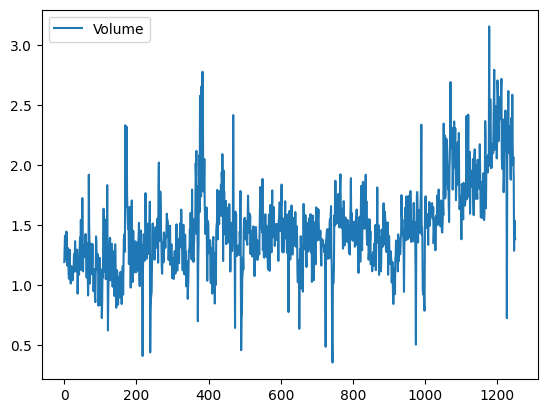

In [89]:
# Correlation Matrix
# The Direction variable because it is qualitative, we need to convert it to numeric for correlation analysis

Smarket_numeric = Smarket.copy()
Smarket_numeric['Direction'] = Smarket_numeric['Direction'].map({'Up': 1, 'Down': 0})
Smarket.plot(y='Volume');
Smarket_numeric.corr().style.background_gradient(cmap='coolwarm').format('{:.3f}')

<span style="font-size: 14px;">

## 4.2 Classification Model Evaluation

The bias–variance decomposition is formally derived for regression with squared loss, <br>
but the bias–variance tradeoff applies to both regression and classification models.

In classification, performance is typically evaluated using metrics such as the confusion matrix, accuracy, <br>
precision, recall, or cross-entropy loss, rather than an explicit bias–variance decomposition.

In [90]:
# evaluare_model utility function
def evaluate_model(my_prob, my_pred, L_test):
    """
    Utility function to evaluate the model performance
    my_prob: predicted probabilities for the positive class (Up)
    my_pred: predicted class labels (0 or 1)
    L_test: true class labels for the test set
    """
    from sklearn.metrics import confusion_matrix

    # Print confusion matrix with percentages
    confMat = confusion_matrix(my_pred, L_test)
    total = confMat.sum()
    confMat_pct = (confMat / total * 100).round(2)
    print("Confusion Matrix:(true value in the columns, predicted in the rows)\n          Down              Up")
    print(f"Down   {confMat[0][0]:.0f}({confMat_pct[0][0]:.2f}%)     {confMat[0][1]:.0f}({confMat_pct[0][1]:.2f}%)")
    print(f"Up     {confMat[1][0]:.0f}({confMat_pct[1][0]:.2f}%)     {confMat[1][1]:.0f}({confMat_pct[1][1]:.2f}%)")

    # Print accuracy and error rate
    accuracy = np.mean(my_pred == L_test)
    error = 1 - accuracy
    print(f"\nAccuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Error Rate: {error:.4f} ({error*100:.2f}%)")

    # Check that predicted labels match the probabilities
    # If P(Up) >= threshold → predict Up (1), else Down (0)
    check = np.all(np.where(my_prob[:,1] >= threshold, True,False) == my_pred) 
    print(f"\nCheck predictions match probabilities: {check}")

    # Count how many observations have a very high probability of being 'Down'
    # Here, P(Down) > 0.9 is considered high confidence
    count = np.sum(my_prob[:,0] > 0.9)
    print(f"Observations with P(Down) > 0.9: {count}")

    TPR = confMat[1][1] / (confMat[1][0] + confMat[1][1]) if (confMat[1][0] + confMat[1][1]) > 0 else 0
    FPR = confMat[0][1] / (confMat[0][0] + confMat[0][1]) if (confMat[0][0] + confMat[0][1]) > 0 else 0
    
    # --- ROC Curve ---
    y_score = my_prob[:, 1]  # probabilità della classe positiva
    fpr, tpr, roc_thresh = roc_curve(L_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
    
    # evidenzio il punto della soglia usata
    idx = (np.abs(roc_thresh - threshold)).argmin()
    plt.scatter(fpr[idx], tpr[idx], color='red', label=f'Threshold={threshold}')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    return confMat, accuracy, error, TPR, FPR

In [91]:
# model_summary utility function
def model_summary(model):
    """
    Prints a summary of the model's attributes, including their types and shapes if applicable.
    model: the fitted model object to summarize
    """
    print(f"### Summary per modello: {type(model).__name__} ###\n")
    
    # Iterate over all attributes of the model
    for attr_name in dir(model):
        # Filter attributes that end with '_' (common convention for fitted parameters) and ignore special methods
        if attr_name.endswith('_') and not attr_name.startswith('__'):
            attr = getattr(model, attr_name)
            attr_type = type(attr).__name__
            shape_info = ""
            
            # add shape or size information if the attribute is an array-like structure
            if hasattr(attr, "shape"):
                shape_info = f", shape={attr.shape}"
            elif hasattr(attr, "size"):
                shape_info = f", size={attr.size}"
            
            # Print name, type, dimension, and value
            print(f"{attr_name} ({attr_type}{shape_info}):\n{attr}\n")

<span style="font-size: 14px;">

## 4.3 Classification Algorithm

- classification algorithms
    - discriminative learning algorithms: they learn  <br>
    which features are most useful to discriminate between the classes.
        - LR: logistic regression. $\vec x \in \mathcal{R}^n$ 
        - DT: decision trees DT. $\vec x \in \mathcal{N}^n$ or $\vec x \in \mathcal{R}^n$
        - NN: neural networks. $\vec x \in \mathcal{R}^n$
    - generative learning algorithms: they learn  <br> 
    how to generate some input data, i.e., the distribution of the inputs x.
        - NB: Nive Bayes. $\vec x \in \mathcal{N}^n$
        - GDA: Gaussian discriminant analysis. $\vec x \in \mathcal{R}^n$
            - LDA: Linear Discriminant Analysis. Assumes all classes share the same covariance matrix. LDA leads to linear decision boundaries.
            - QDA: Quadratic Discriminant Analysis. Allows each class to have its own covariance matrix. Leads to quadratic decision boundaries.
        - BMM: Gaussian mixture models. $\vec x \in \mathcal{R}^n$
    - non parametric learning algoritms: they don't learn anything, just makes a lazy classification
        - KNN: K Nearest Neighbors
        
## 4.4 Discriminative learning algorithms

<span style="font-size: 14px;">

### 4.4.1 LR Logistic Regression

$\displaystyle y = f(\vec{x}) = \sigma(\vec{w}^T \vec{x}) \triangleq \frac{1}{1+e^{-\vec{w}^T \vec{x}}}$

If both $y$ and $t \in \{0,1\}$ then for every $i^{th}$ of $N$ samples we have:

$\displaystyle p(t_i=1 \mid \vec{x}_i; \vec{w}) = f(\vec{x}_i) \\
p(t_i=0 \mid \vec{x}_i; \vec{w}) = 1-f(\vec{x}_i) \quad$ merging the two  formulas $ \\
p(t_i \mid \vec{x}_i; \vec{w}) = (f(\vec{x}_i))^{t_i} (1-f(\vec{x}_i))^{1-t_i} \quad  i \in [1,N] $

$ \displaystyle L(\vec{w}) = p(\vec{t} \mid X; \vec{w}) = \Pi_{i=1}^N [f(\vec{x}_i)]^{t_i} [1-f(\vec{x}_i)]^{1-t_i} $

$ \displaystyle l(\vec{w}) = - \log  L(\vec{w}) = - \sum_{i=1}^N  \log [f(\vec{x}_i)]^{t_i} [1-f(\vec{x}_i)]^{1-t_i}  = \\
\hspace{2em} \boxed{
l(\vec{w}) = - \sum_{i=1}^N \left[ t_i \log y_i + (1-t_i)\log(1-y_i) \right]
} \quad$ Binary Cross Entropy loss

solved using Gradient Descent algorithm

---

$  y_{i,k}$ is the predicted probability that the i-th sample belongs to the k-th class.

$ y_i $  is the predicted probability of the true class

$\displaystyle \vec{y}_i = f(\vec{x}_i) = \text{softmax} (W \vec{x}_i + \vec{b}) \quad i \in [1,N]$

$\displaystyle y_{i,k} = \frac{e^{\vec{w}_k^T \vec{x}_i + b_k}}{\sum_{j=1}^K e^{\vec{w}_j^T \vec{x}_i + b_j}}$

$ W \triangleq \left[ \begin{array} {c c c c} w_{1,1} \ w_{1,2} \ ... \ w_{1,d} \\ w_{2,1} \ w_{2,2} \ ... \ w_{2,d} \\
... \\ w_{K,1} \ w_{K,2} \ ... \ w_{K,d} \end{array} \right] \quad \vec{b} \triangleq \left[ \begin{array}{c} b_1 \\ b_2 \\ ... \\ b_K \end{array}\right] \quad t_i $ is one hot i.e. $t_{i,k} = \begin{cases} 1 \text{ if sample } i \text{ belongs to class } k \\ 0 \text{ otherwise } \end{cases}$

$ \displaystyle l(\vec{w}) = - \sum_{i=1}^N \sum_{k=1}^K t_{i,k} \log y_{i,k} = - \sum_{i=1}^N \log y_i \quad $ Cross Entropy loss

solved using Stochastic Gradient Descent algorithm 


In [92]:
# LR Learning
model = MS(['Lag1', 'Lag2']).fit(Smarket) # using only Lag1 and Lag2 as significant predictors    
X = model.transform(Smarket)
y = Smarket.Direction == 'Up' # Convert 'Up' to True and 'Down' to False for logistic regression

# Train/Test Split 2001-2004 vs 2005
train = (Smarket.Year < 2005)
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
D_train, D_test = Smarket.Direction.loc[train], Smarket.Direction.loc[~train]
L_train, L_test = Smarket.Direction.loc[train].map({'Down': 0, 'Up': 1}), Smarket.Direction.loc[~train].map({'Down': 0, 'Up': 1})

# Model: Train only
glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm_train.fit()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 80)
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                  998
Model:                            GLM   Df Residuals:                      995
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -690.70
Date:                Sat, 04 Apr 2026   Deviance:                       1381.4
Time:                        19:29:30   Pearson chi2:                     998.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.001865
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0322      0.063      0.508      0.611      -0.092       0.156
Lag1          -0.0556      0.052     -1.076      0.282      -0.157       0.046
Lag2          -0.0445      0.052     -0.861      0.389      -0.146       0.057
==============================================================================
"""

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   35(13.89%)     35(13.89%)
Up     76(30.16%)     106(42.06%)

Accuracy  : 0.5595 (55.95%)
Error Rate: 0.4405 (44.05%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


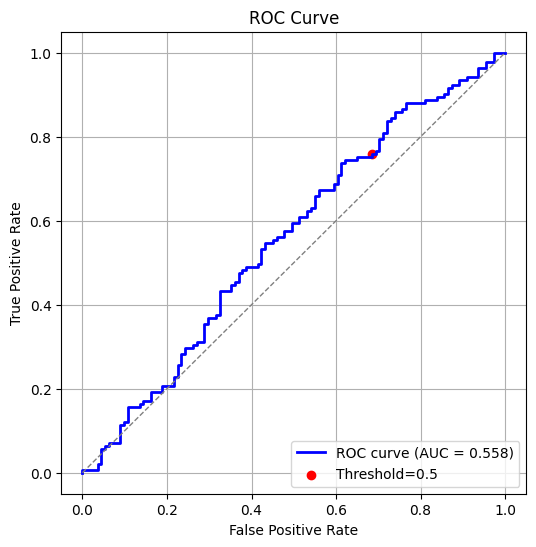

(array([[ 35,  35],
        [ 76, 106]]),
 np.float64(0.5595238095238095),
 np.float64(0.44047619047619047),
 np.float64(0.5824175824175825),
 np.float64(0.5))

In [93]:
# LR Predictions
LR_prob = results.predict(exog=X_test)
LR_pred = (LR_prob > threshold ).astype(int)

LR_prob_2d = np.column_stack((1 - LR_prob, LR_prob))
evaluate_model(LR_prob_2d, LR_pred, L_test)


<span style="font-size: 14px;">

### 4.4.2 Decision Tree

Decision trees make predictions by recursively splitting on different attributes according to a tree structure

Given a training dataset, we need to learn:
- Which attribute to choose for splitting (e.g., width)
    - $p( j \mid R)$ is the class frequency of class $j$ in the region $R$ 
    - Gini Index: GINI $ (R) = 1-\sum_j [p(j \mid R)]^2$ (must be as low as possible)
- What value of that attribute to use for splitting (e.g., width > 6.5 cm)

Classification tree:
- discrete output, i.e., $y \in {1, · · · ,C}$
- leaf value $\hat y_m$ typically set to the most common value (or majority vote) in ${y_{m_1}, · · · , y_{m_k}}$ 

Regression tree:
- continuous output, i.e.m $y \in \mathbb{R}$
- discrete output, i.e., $y \in {1, · · · ,C}$
- leaf value $\hat y_m$ typically set to the mean value in ${y_{m_1}, · · · , y_{m_k}}$ 


Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   62(24.60%)     66(26.19%)
Up     49(19.44%)     75(29.76%)

Accuracy  : 0.5437 (54.37%)
Error Rate: 0.4563 (45.63%)

Check predictions match probabilities: False
Observations with P(Down) > 0.9: 13


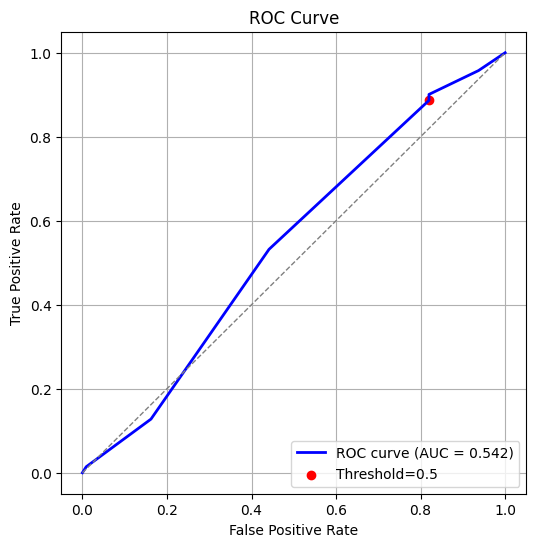

### Summary per modello: DecisionTreeClassifier ###

_repr_html_ (method):
<bound method ReprHTMLMixin._repr_html_inner of DecisionTreeClassifier(max_depth=3, random_state=42)>

_repr_mimebundle_ (method):
<bound method ReprHTMLMixin._repr_mimebundle_ of DecisionTreeClassifier(max_depth=3, random_state=42)>

classes_ (ndarray, shape=(2,)):
[0 1]

feature_importances_ (ndarray, shape=(3,)):
[0.         0.83040717 0.16959283]

feature_names_in_ (ndarray, shape=(3,)):
['intercept' 'Lag1' 'Lag2']

max_features_ (int):
3

n_classes_ (int64, shape=()):
2

n_features_in_ (int):
3

n_outputs_ (int):
1

tree_ (Tree):



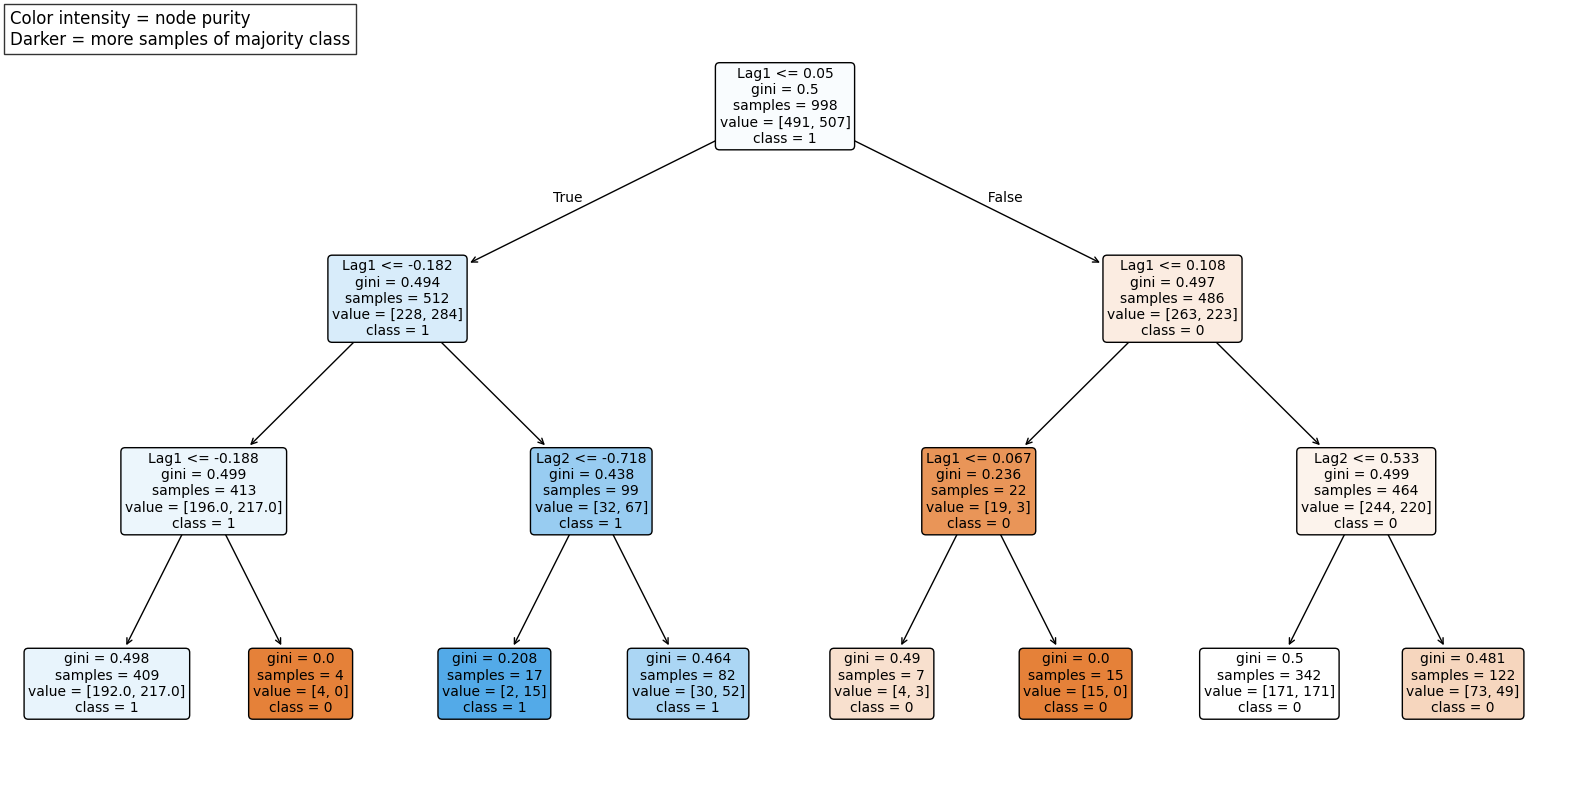

In [94]:

DT = DecisionTreeClassifier(random_state=42, # Using the intergalatic guide to split the dataset
                            max_depth=3)  # other parameters: max_leaf_nodes, min_samples_split, ecc.

DT.fit(X_train, L_train)
dt_prob = DT.predict_proba(X_test)     # probabilità per ciascuna classe
dt_pred = DT.predict(X_test)           # classi predette
evaluate_model(dt_prob, dt_pred, L_test)
model_summary(DT)

feature_names = X_train.columns.tolist()        # prende le colonne di X_train
class_names = [str(c) for c in sorted(L_train.unique())]  # classi ordinate come stringhe

plt.figure(figsize=(20,10))
plot_tree(DT, feature_names=feature_names, class_names=class_names, 
          filled=True, rounded=True, fontsize=10)
plt.text(0, 1, 
         "Color intensity = node purity\nDarker = more samples of majority class",
         fontsize=12, color='black', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.8))
plt.show()

<span style="font-size: 14px;">

## 4.5 Generative learning algorithms

### 4.5.1 LDA Linear Determinant Analisys

Bayes' Rule: $\quad p(t=k \mid x) \cdot p(x) = p(x \mid t=k) \cdot p(t=k) \quad $ where:
- $p(x \mid t=k) \hspace{4.6em} $ LIKELIHOOD (probability to have $x$ having the label is $k$)
- $p(t=k) \triangleq \pi_k \hspace{3.7em} $ PRIOR (probability to have the label $k$)
- $p(x) \hspace{7.7em} $ EVIDENCE (probability to have $x$)
- $p(t=k \mid x) \triangleq p_k(x) \hspace{1em} $ POSTERIOR (probability to have the label $k$ having $x$)

Assumption # 1: The class-conditional distribution $p(x \mid t)$ is normal or GAUSSIAN <br>
Assumption # 2: The standard deviation is shared across all the K classes, i.e., $\quad \sigma_k = \sigma \ \forall k \in [1,K]$

$\displaystyle p(x \mid t=k) \triangleq f_k(x) \triangleq \frac{1}{\sqrt {2 \pi \sigma^2}} \exp \left[ - \frac{(x-\mu_k)^2}{2 \sigma^2} \right]$

then using the Bayes' Rule we obtain

$\displaystyle p_k(x)= \frac{ \pi_k \cdot f_k(x)}{p(x)} \quad $ Recall that $\quad p(x) = \sum_{k=1}^K \pi_k \ p(x \mid t=k) $

Finding the largest $p_k(x)$ means find the largest DISCRIMINANT SCORE $\displaystyle \quad \delta_k(x) = \frac{\mu_k}{\sigma^2} \cdot x - \frac{\mu_k^2}{2 \sigma^2} + \log \pi_k$

DECISION BOUNDARY formula (for binary classification): $\quad \displaystyle \frac{\mu_0 - \mu_1}{\sigma^2}  \cdot x - \frac{ \mu_1^2 - \mu_0^2}{2 \sigma^2} + \log \frac{\pi_0}{\pi_1} = 0 \quad$ that is linear $ \quad (mx + q = 0)$

---

Generalizing LDA to the d-dimensional case where the input has $d$ features, i.e., $\vec{x} \in \mathbb{R}^d$

Assumption # 1: The class-conditional distribution is a Multivariate Gaussian Distribution $\quad \sim \mathcal{N}(\vec{\mu}_k, \  \Sigma_k)$ <br>
Assumption # 2: All the classes share the same covariance matrix, i.e., $\quad \Sigma_k = \Sigma \ \forall k \in [1,K]$

$\displaystyle f(\vec{x}) = \frac{1}{(2 \pi)^{d/2} |\Sigma|^{1/2}} \ \exp \left[ - \frac{1}{2} (\vec{x}-\vec{\mu})^T \Sigma^{-1} (\vec{x}-\vec{\mu}) \right]$

$ \Sigma_k = \mathbb{E} \left[ (\vec{x} - \vec{\mu}_k) (\vec{x} - \vec{\mu}_k)^T \mid t=k \right] = \frac{1}{N_k} \ 
\underset{i \ \in \ k-class}{\sum}(\vec{x}_i - \vec{\mu}_k) (\vec{x}_i - \vec{\mu}_k)^T$ <br>
$ \vec{\mu} = [\mu_{k,1} \ \mu_{k,2} \ ... \ \mu_{k,d}]^T$ is a vector in $\mathbb{R}^d$ representing the mean of each features for class $k$<br>
$N_k$ number of samples belonging to class $k$

Finding the largest $p_k(x)$ means find the largest DISCRIMINANT SCORE $\displaystyle \quad \delta_k(x) = \vec{x}^T \Sigma^{-1} \vec{\mu}_k - \frac{1}{2} \vec{\mu}_k^T \Sigma^{-1} \vec{\mu}_k + \log \pi_k$

The DECISION BOUNDARY formulas (for LDA multiclass classification) is still linear, i.e., each class is divided from the other by a linear boundary


Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   35(13.89%)     35(13.89%)
Up     76(30.16%)     106(42.06%)

Accuracy  : 0.5595 (55.95%)
Error Rate: 0.4405 (44.05%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


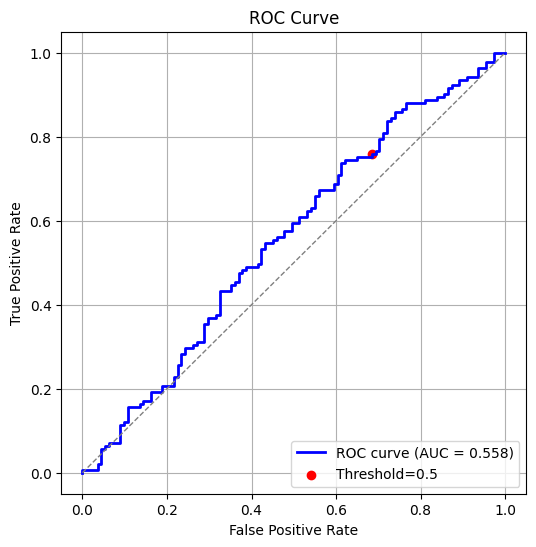

### Summary per modello: LinearDiscriminantAnalysis ###

_repr_html_ (method):
<bound method ReprHTMLMixin._repr_html_inner of LinearDiscriminantAnalysis(store_covariance=True)>

_repr_mimebundle_ (method):
<bound method ReprHTMLMixin._repr_mimebundle_ of LinearDiscriminantAnalysis(store_covariance=True)>

classes_ (ndarray, shape=(2,)):
[0 1]

coef_ (ndarray, shape=(1, 3)):
[[ 0.         -0.05544078 -0.0443452 ]]

covariance_ (ndarray, shape=(3, 3)):
[[ 0.          0.          0.        ]
 [ 0.          1.50886781 -0.03340234]
 [ 0.         -0.03340234  1.5095363 ]]

explained_variance_ratio_ (ndarray, shape=(1,)):
[1.]

feature_names_in_ (ndarray, shape=(3,)):
['intercept' 'Lag1' 'Lag2']

intercept_ (ndarray, shape=(1,)):
[0.03221375]

means_ (ndarray, shape=(2, 3)):
[[ 1.          0.04279022  0.03389409]
 [ 1.         -0.03954635 -0.03132544]]

n_features_in_ (int):
3

priors_ (ndarray, shape=(2,)):
[0.49198397 0.50801603]

scalings_ (ndarray, shape=(3, 1)):
[[ 0.        ]
 [-0.6420

In [95]:
lda = LDA(store_covariance=True)

lda.fit(X_train, L_train)
lda_prob = lda.predict_proba(X_test) # probabilità predette per ciascuna classe
lda_pred = lda.predict(X_test) # predizioni su test set
evaluate_model(lda_prob, lda_pred, L_test)
model_summary(lda)


<span style="font-size: 14px;">

### 4.5.2 QDA Quadratic Discriminant Analysis

### QDA (Quadratic Discriminant Analysis) — Multiclass Extension

Removing the Assunption # 2 from the LDA multiclass Analysis we have

Assumption # 1: The class-conditional distribution is a Multivariate Gaussian Distribution $\quad \sim \mathcal{N}(\vec{\mu}_k, \  \Sigma_k)$ <br>

$f_k(\vec{x}) = \frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}} 
\exp \left[ - \frac{1}{2} (\vec{x}-\vec{\mu}_k)^T \Sigma_k^{-1} (\vec{x}-\vec{\mu}_k) \right]$

$ \Sigma_k = \mathbb{E} \left[ (\vec{x} - \vec{\mu}_k) (\vec{x} - \vec{\mu}_k)^T \mid t=k \right] = \frac{1}{N_k} \ 
\underset{i \ \in \ k-class}{\sum}(\vec{x}_i - \vec{\mu}_k) (\vec{x}_i - \vec{\mu}_k)^T$ <br>
$ \vec{\mu} = [\mu_{k,1} \ \mu_{k,2} \ ... \ \mu_{k,d}]^T$ is a vector in $\mathbb{R}^d$ representing the mean of each features for class $k$<br>
$N_k$ number of samples belonging to class $k$

Finding the largest $p_k(x)$ means find the largest DISCRIMINANT SCORE $ \displaystyle \delta_k(\vec{x}) = - \frac{1}{2} \log |\Sigma_k| - \frac{1}{2} (\vec{x}-\vec{\mu}_k)^T \Sigma_k^{-1} (\vec{x}-\vec{\mu}_k) + \log \pi_k$

The DECISION BOUNDARY formulas (for QDA multiclass classification) becomes: $\quad \delta_k(\vec{x}) - \delta_j(\vec{x}) = 0 \quad \Rightarrow \quad \text{quadratic in } \vec{x}$

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   30(11.90%)     20(7.94%)
Up     81(32.14%)     121(48.02%)

Accuracy  : 0.5992 (59.92%)
Error Rate: 0.4008 (40.08%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


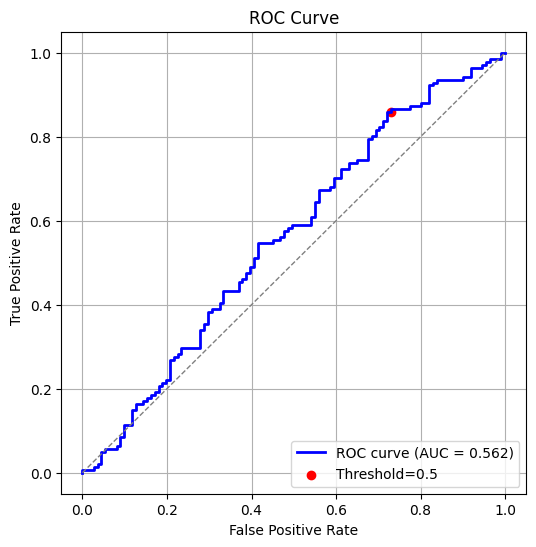

### Summary per modello: QuadraticDiscriminantAnalysis ###

_repr_html_ (method):
<bound method ReprHTMLMixin._repr_html_inner of QuadraticDiscriminantAnalysis(store_covariance=True)>

_repr_mimebundle_ (method):
<bound method ReprHTMLMixin._repr_mimebundle_ of QuadraticDiscriminantAnalysis(store_covariance=True)>

classes_ (ndarray, shape=(2,)):
[0 1]

covariance_ (list):
[array([[ 1.50662277, -0.03924806],
       [-0.03924806,  1.53559498]]), array([[ 1.51700576, -0.02787349],
       [-0.02787349,  1.49026815]])]

feature_names_in_ (ndarray, shape=(2,)):
['Lag1' 'Lag2']

means_ (ndarray, shape=(2, 2)):
[[ 0.04279022  0.03389409]
 [-0.03954635 -0.03132544]]

n_features_in_ (int):
2

priors_ (ndarray, shape=(2,)):
[0.49198397 0.50801603]

rotations_ (list):
[array([[ 0.57172606,  0.82044458],
       [-0.82044458,  0.57172606]]), array([[-0.84630247, -0.53270267],
       [ 0.53270267, -0.84630247]])]

scalings_ (list):
[array([1.56294495, 1.47927279]), array([1.53455065, 1.47272326])]



In [96]:
X_train_no_intercept = X_train.drop('intercept', axis=1)
X_test_no_intercept = X_test.drop('intercept', axis=1)
qda = QDA(store_covariance=True)

qda.fit(X_train_no_intercept, L_train)
qda_prob = qda.predict_proba(X_test_no_intercept) # probabilità predette per ciascuna classe
qda_pred = qda.predict(X_test_no_intercept) # predizioni su test set
evaluate_model(qda_prob, qda_pred, L_test)
model_summary(qda)


<span style="font-size: 14px;">

## 4.5.3 NB Naive Bayes

Classical NB assumes that features are discrete (e.g., words in a text, categories, rating levels).

Assumption # 1: Each feature $x_i$ is modeled as a Gaussian (normal) random variable conditioned on the class $t=k$: <br>

$\hspace{4em} p( x_i \mid t=k )\sim \mathcal{N}(\mu_{k,i}, \ \sigma_{k,i}^2)$

Assumption #2: Conditional independence of features given the class, i.e., knowing the class $t=k$ makes all features independent of each other:

$\hspace{4em} p(\vec{x} \mid t=k) = \prod_{i=1}^d p(x_i \mid t=k)$

This means that the joint probability of observing the feature vector $\vec{x}$ for a given class $k$ can be computed as the product of the individual feature probabilities.

Applying the Bayes' rule we obtain the following formula:

$\hspace{4em} p(t=k \mid \vec{x}) \propto p(t=k) \prod_{i=1}^d p(x_i \mid t=k)$

If the features are discrete, $p(x_i \mid t=k)$ can be estimated as the relative frequency.

For datasets like Stock Market, the features (Lag1, Lag2, Volume, etc.) are continuous numerical, so:

Gaussian Naive Bayes (GNB) is used:

$\hspace{4em} \displaystyle p(x_i \mid t=k) = \frac{1}{\sqrt{2 \pi \sigma_{k,i}^2}} \exp \left[ - \frac{(x_i - \mu_{k,i})^2}{2 \sigma_{k,i}^2} \right]$

Here, it is assumed that each continuous feature, conditioned on the class, follows a Gaussian distribution.Here, each continuous feature conditioned on the class is assumed to follow a Gaussian distribution.

The means $\mu_{k,i}$ and variances $\sigma_{k,i}^2$ are estimated from the data.

NB does not require correlations between features; the conditional independence assumption allows the model to treat each feature separately. Even if the real features are not perfectly Gaussian or independent, 

NB often works surprisingly well as a baseline for classification tasks, including predicting stock market direction.

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   29(11.51%)     20(7.94%)
Up     82(32.54%)     121(48.02%)

Accuracy  : 0.5952 (59.52%)
Error Rate: 0.4048 (40.48%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 0


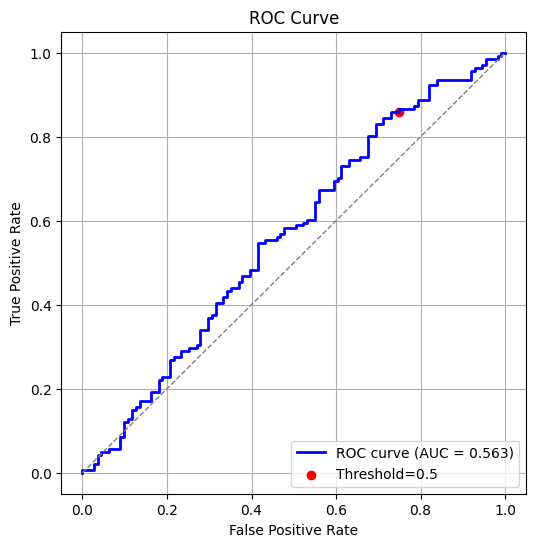

### Summary per modello: GaussianNB ###

_repr_html_ (method):
<bound method ReprHTMLMixin._repr_html_inner of GaussianNB()>

_repr_mimebundle_ (method):
<bound method ReprHTMLMixin._repr_mimebundle_ of GaussianNB()>

class_count_ (ndarray, shape=(2,)):
[491. 507.]

class_prior_ (ndarray, shape=(2,)):
[0.49198397 0.50801603]

classes_ (ndarray, shape=(2,)):
[0 1]

epsilon_ (float64, shape=()):
1.5105994200826503e-09

feature_names_in_ (ndarray, shape=(3,)):
['intercept' 'Lag1' 'Lag2']

n_features_in_ (int):
3

theta_ (ndarray, shape=(2, 3)):
[[ 1.          0.04279022  0.03389409]
 [ 1.         -0.03954635 -0.03132544]]

var_ (ndarray, shape=(2, 3)):
[[1.51059942e-09 1.50355429e+00 1.53246749e+00]
 [1.51059942e-09 1.51401364e+00 1.48732877e+00]]



In [97]:
NB = GaussianNB()

NB.fit(X_train, L_train)
nb_prob = NB.predict_proba(X_test)           # probabilità [P(Down), P(Up)]
nb_pred = NB.predict(X_test)                 # classi
evaluate_model(nb_prob, nb_pred, L_test)
model_summary(NB)


<span style="font-size: 14px;">

## 4.6 Non parametric algorithms

### 4.6.1 KNN K_nearest Neighbors

- To classify a given test example x:
    - Find the K nearest neighbours of x
    - Choose as the label the majority label within the K nearest neighbors
- Robust to noisy data by considering K nearest neighbours instead of the nearest neighbour
- Question: How do we measure “nearest”?
    - Euclidean distance: is the lenght of the line segment between the 2 points
    - Manhattan distance: is the sum of absolute differences between points across all the dimensions
    - Minkowski distance: is the generalization of the above distances:
        - $D_r(\underline{a}, \underline{b}) = \left( \sum_{k=1}^d |a_k - b_k|^r \right)^{1/r}$
        - $r$ is a parameter ($r=1 \to $ Manhattan; $r=2 \to $ Euclidean)
    - Chebyshev Distance: $D_{\infty}(\underline{a}, \underline{b}) = \max_k (| a_k - b_k)$
    - Hamming distance: tra due stringhe binarie (o vettori) della stessa lunghezza è il numero di posizioni in cui i simboli corrispondenti sono diversi.
    - Cosine Similarity: measures how two vectors are similar to each other
        - $\cos \theta = \frac {\underline{a} \cdot \underline{b}}{|| a || \ ||b||} $

Confusion Matrix:(true value in the columns, predicted in the rows)
          Down              Up
Down   43(17.06%)     58(23.02%)
Up     68(26.98%)     83(32.94%)

Accuracy  : 0.5000 (50.00%)
Error Rate: 0.5000 (50.00%)

Check predictions match probabilities: True
Observations with P(Down) > 0.9: 101


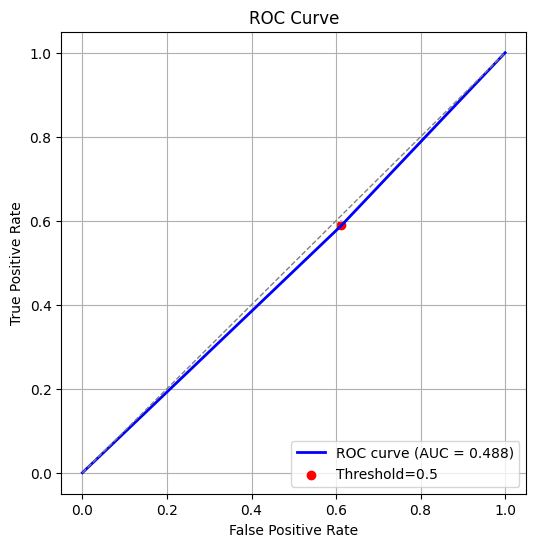

### Summary per modello: KNeighborsClassifier ###

_repr_html_ (method):
<bound method ReprHTMLMixin._repr_html_inner of KNeighborsClassifier(metric='euclidean', n_neighbors=1)>

_repr_mimebundle_ (method):
<bound method ReprHTMLMixin._repr_mimebundle_ of KNeighborsClassifier(metric='euclidean', n_neighbors=1)>

classes_ (ndarray, shape=(2,)):
[0 1]

effective_metric_ (str):
euclidean

effective_metric_params_ (dict):
{}

feature_names_in_ (ndarray, shape=(3,)):
['intercept' 'Lag1' 'Lag2']

n_features_in_ (int):
3

n_samples_fit_ (int):
998

outputs_2d_ (bool):
False



In [98]:
knn1 = KNeighborsClassifier(n_neighbors=1, metric='euclidean')

'''
possible metrics: 'euclidean', 'manhattan', 'chebyshev', 'minkowski', 'hamming'.
'''

knn1.fit(X_train, L_train)
knn1_prob = knn1.predict_proba(X_test)     # probabilità [P(Down), P(Up)]
knn1_pred = knn1.predict(X_test)           # classi
evaluate_model(knn1_prob, knn1_pred, L_test)
model_summary(knn1)